In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression  # Basic linear regression
from sklearn.linear_model import Ridge, Lasso      # Regularized regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score , r2_score  # Loss and evaluation metrics
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler      # Feature scaling
from sklearn.model_selection import cross_val_score   # Cross-validation
from math import sqrt
from sklearn.tree import DecisionTreeClassifier

from google.colab import files
uploaded = files.upload()

np.set_printoptions(formatter={'float_kind' : '{:f}'.format})

Saving Marketing Raw Data (1).csv to Marketing Raw Data (1).csv


In [ ]:
rw = pd.read_csv("Marketing Raw Data (1).csv")
rw.head()

,Date,Week,Week_ID,Month,Month_ID,Year,Day_Name,Visitors,Revenue,Marketing Spend,Promo
0,09/11/2020,46,34,11,11,2020,Monday,707,465,651.375,No Promo
1,10/11/2020,46,34,11,11,2020,Tuesday,1455,10386,1298.250,Promotion Red
2,11/11/2020,46,34,11,11,2020,Wednesday,1520,12475,1559.375,Promotion Blue
3,12/11/2020,46,34,11,11,2020,Thursday,1726,11712,1801.750,No Promo
4,13/11/2020,46,34,11,11,2020,Friday,2134,10000,2614.500,No Promo


In [ ]:
# EDA
rw.isnull().sum()

,0
Date,0
Week,0
Week_ID,0
Month,0
Month_ID,0
Year,0
Day_Name,0
Visitors,0
Revenue,0
Marketing Spend,0


In [ ]:
rw[rw['Week'].isnull()]

,Date,Week,Week_ID,Month,Month_ID,Year,Day_Name,Visitors,Revenue,Marketing Spend,Promo


In [ ]:
rw.shape

(182, 11)

In [ ]:
for column in rw:
    uv = np.unique(rw[column])
    nbr = len(uv)
    if nbr <10:
           print("the no. of values for {} : {} -- {}".format(column, nbr, uv))

    else:
         print("the no. of values for {} : {} ".format(column, nbr))


the no. of values for Date : 182 
the no. of values for Week : 28 
the no. of values for Week_ID : 28 
the no. of values for Month : 7 -- [ 1  2  3  4  5 11 12]
the no. of values for Month_ID : 7 -- [11 12 13 14 15 16 17]
the no. of values for Year : 2 -- [2020 2021]
the no. of values for Day_Name : 7 -- ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
the no. of values for Visitors : 175 
the no. of values for Revenue : 181 
the no. of values for Marketing Spend : 182 
the no. of values for Promo : 3 -- ['No Promo' 'Promotion Blue' 'Promotion Red']


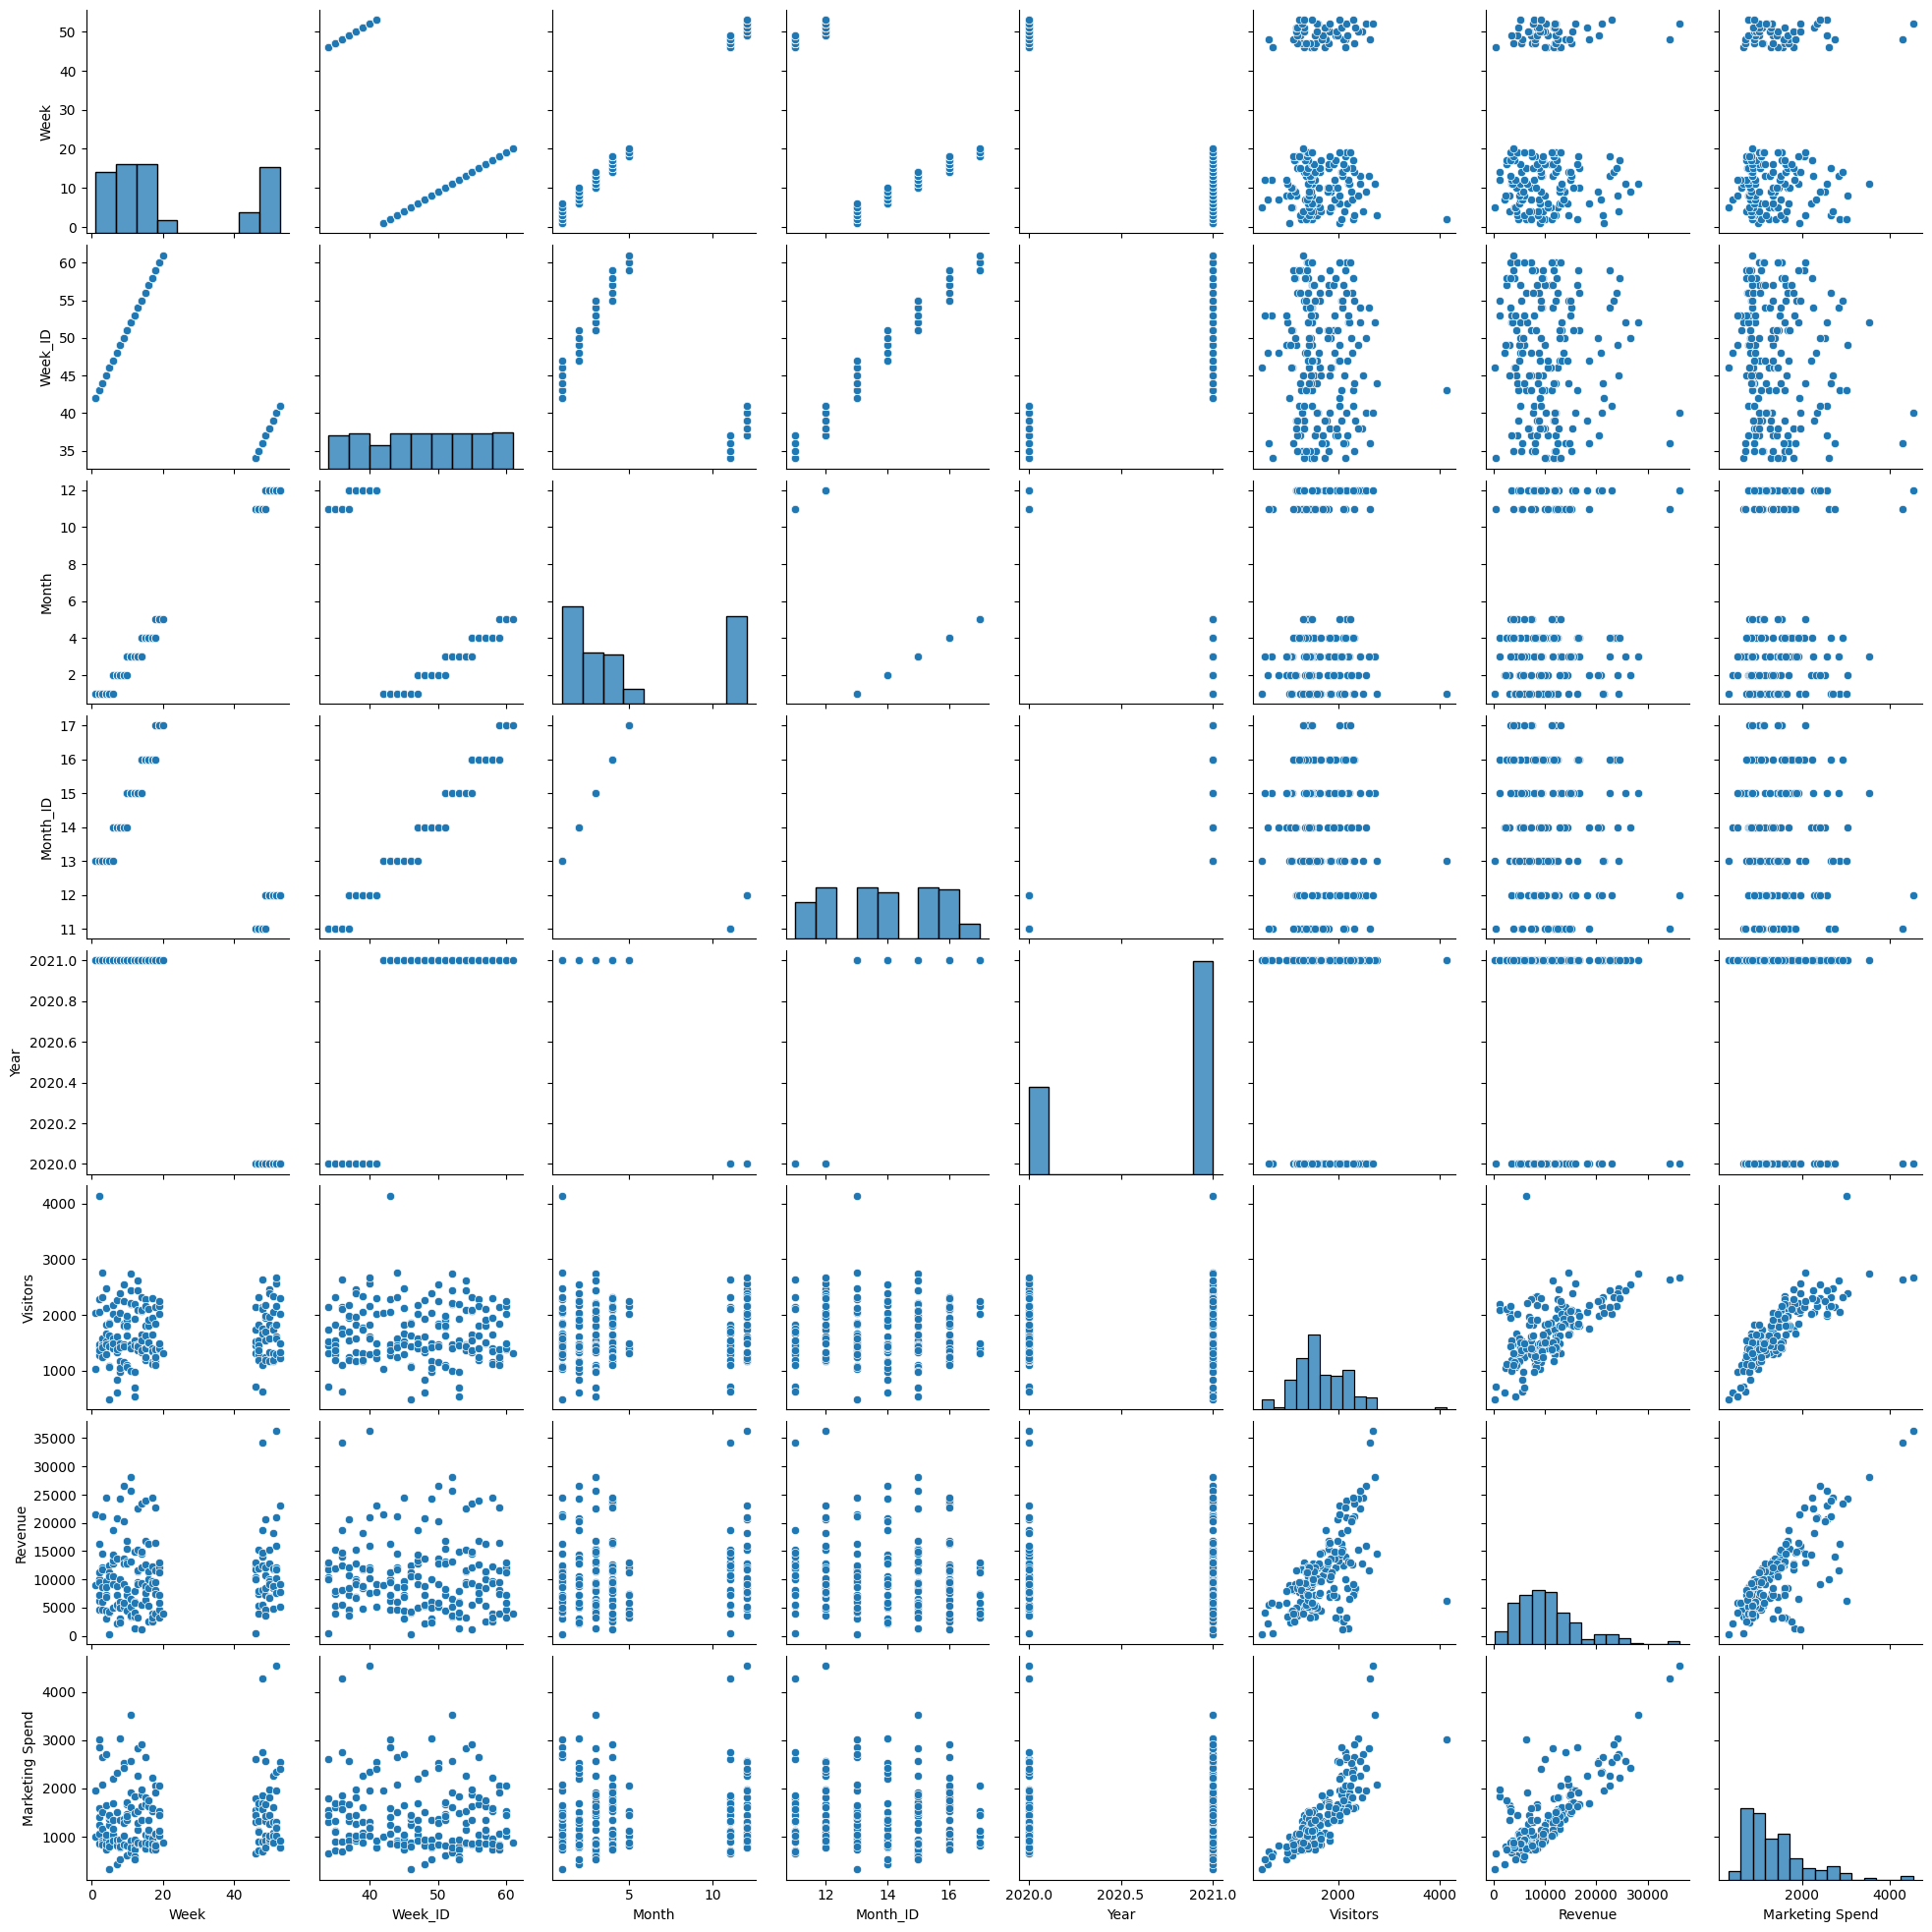

In [ ]:

g = sns.pairplot(rw)


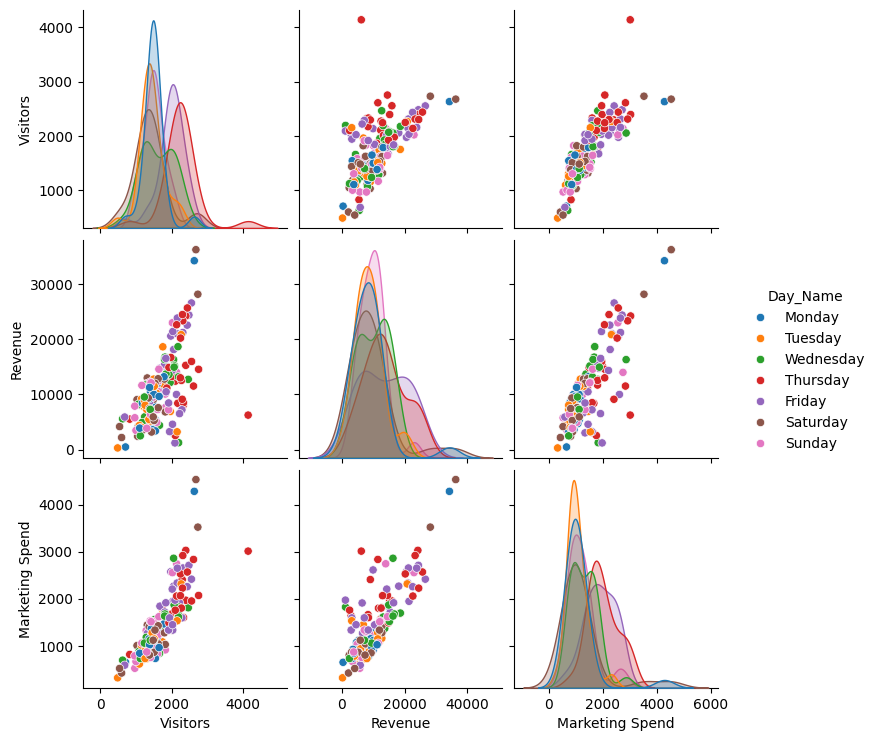

In [ ]:
g = sns.pairplot(rw[['Visitors', 'Revenue', 'Marketing Spend', 'Day_Name']], hue = 'Day_Name')


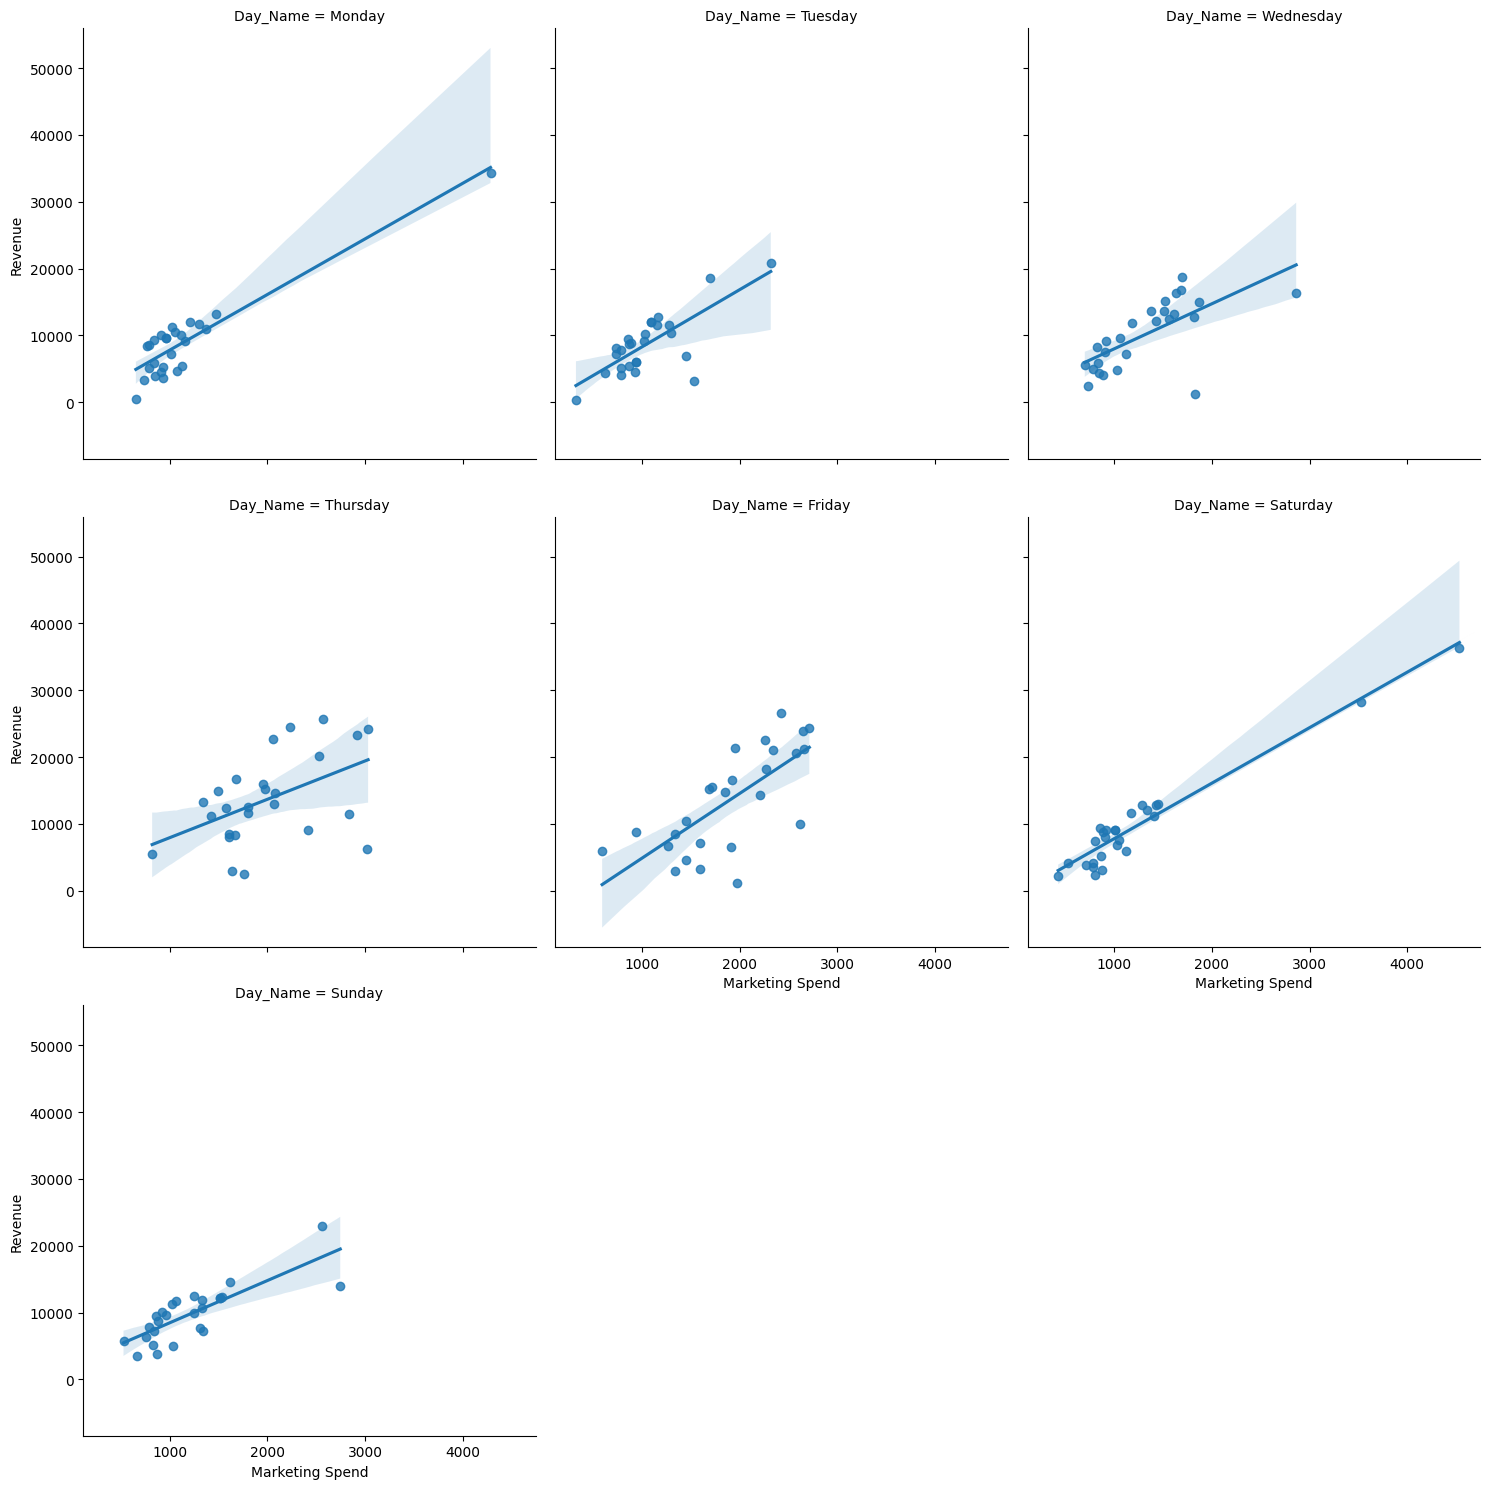

In [ ]:
g = sns.lmplot(x = 'Marketing Spend', y = 'Revenue', data = rw, col = 'Day_Name', col_wrap = 3)

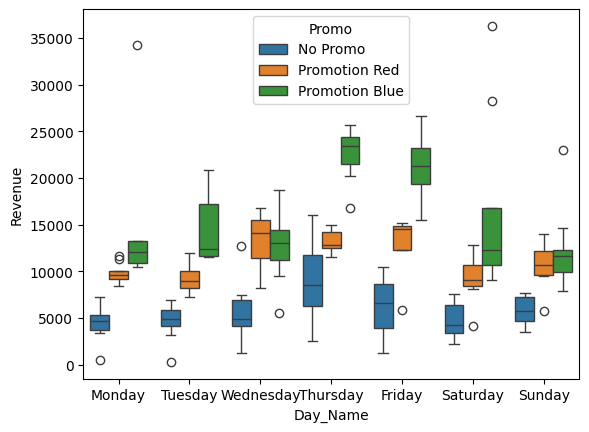

In [ ]:
g = sns.boxplot(x = 'Day_Name', y = 'Revenue', data= rw, hue = 'Promo')

In [ ]:
# deleteing outliers

rw = rw[rw['Revenue'] < 27000]
rw.shape

(179, 11)

In [ ]:

rw = rw[['Day_Name', 'Visitors', 'Revenue', 'Marketing Spend', 'Promo']]
rw.head()

,Day_Name,Visitors,Revenue,Marketing Spend,Promo
0,Monday,707,465,651.375,No Promo
1,Tuesday,1455,10386,1298.250,Promotion Red
2,Wednesday,1520,12475,1559.375,Promotion Blue
3,Thursday,1726,11712,1801.750,No Promo
4,Friday,2134,10000,2614.500,No Promo


In [ ]:
# categories of variables into numeric representation

nrw = pd.get_dummies(rw, columns = ['Promo', 'Day_Name'], dtype = int)
nrw.head()

,Visitors,Revenue,Marketing Spend,Promo_No Promo,Promo_Promotion Blue,Promo_Promotion Red,Day_Name_Friday,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,707,465,651.375,1,0,0,0,1,0,0,0,0,0
1,1455,10386,1298.250,0,0,1,0,0,0,0,0,1,0
2,1520,12475,1559.375,0,1,0,0,0,0,0,0,0,1
3,1726,11712,1801.750,1,0,0,0,0,0,0,1,0,0
4,2134,10000,2614.500,1,0,0,1,0,0,0,0,0,0


In [ ]:
hm = nrw[['Visitors', 'Revenue', 'Marketing Spend']].corr()


In [ ]:
nrw.head()

,Visitors,Revenue,Marketing Spend,Promo_No Promo,Promo_Promotion Blue,Promo_Promotion Red,Day_Name_Friday,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,707,465,651.375,1,0,0,0,1,0,0,0,0,0
1,1455,10386,1298.250,0,0,1,0,0,0,0,0,1,0
2,1520,12475,1559.375,0,1,0,0,0,0,0,0,0,1
3,1726,11712,1801.750,1,0,0,0,0,0,0,1,0,0
4,2134,10000,2614.500,1,0,0,1,0,0,0,0,0,0


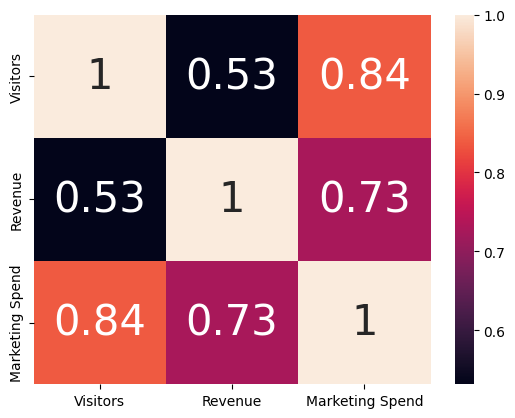

In [ ]:
g = sns.heatmap(hm, annot = True, annot_kws = {'size' : 30})

In [ ]:
# Feature selection/ importance

# Split data x and y
x = nrw.drop('Revenue', axis = 1).values
y = nrw['Revenue']

print(x.shape)
print(y.shape)

x


(179, 12)
(179,)


array([[707.000000, 651.375000, 1.000000, ..., 0.000000, 0.000000,
        0.000000],
       [1455.000000, 1298.250000, 0.000000, ..., 0.000000, 1.000000,
        0.000000],
       [1520.000000, 1559.375000, 0.000000, ..., 0.000000, 0.000000,
        1.000000],
       ...,
       [2023.000000, 1450.200000, 1.000000, ..., 0.000000, 0.000000,
        0.000000],
       [1483.000000, 1121.875000, 1.000000, ..., 0.000000, 0.000000,
        0.000000],
       [1303.000000, 871.000000, 1.000000, ..., 0.000000, 0.000000,
        0.000000]])

In [ ]:
dt = DecisionTreeClassifier(random_state = 0, criterion = 'entropy', max_depth = 10 )
#using gini ( entropy) cause we want to minimize it !
dt.fit(x, y)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0)

In [ ]:
for i, column in enumerate( nrw.drop('Revenue', axis = 1)):
  print('The feature importance for {} is : {}'.format(column, dt.feature_importances_[i]))

The feature importance for Visitors is : 0.38003244845458223
The feature importance for Marketing Spend is : 0.43071678414475706
The feature importance for Promo_No Promo is : 0.018838918855705447
The feature importance for Promo_Promotion Blue is : 0.0368963042229557
The feature importance for Promo_Promotion Red is : 0.02973560674825657
The feature importance for Day_Name_Friday is : 0.016155496125980457
The feature importance for Day_Name_Monday is : 0.017284212925427426
The feature importance for Day_Name_Saturday is : 0.01784857132515091
The feature importance for Day_Name_Sunday is : 0.01429378906435641
The feature importance for Day_Name_Thursday is : 0.0071842245427674095
The feature importance for Day_Name_Tuesday is : 0.017650708056515967
The feature importance for Day_Name_Wednesday is : 0.013362935533544383


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=15)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(143, 12)
(36, 12)
(143,)
(36,)


In [ ]:
 # Linear regression.
 lm = LinearRegression( fit_intercept = True)
 lm.fit(x_train, y_train)
 y_pred = lm.predict(x_train) # predicts y based on x_train!

In [ ]:
y_train
y_pred.shape


(143,)

In [ ]:
# Cal Accuracy on Training Dataset!
print('the Accuracy on the training dataset is :', lm.score(x_train, y_train ))
print('the Accuracy no.2 on the training dataset is :', r2_score(y_train, y_pred ))

# Cal Accuracy on Testing Dataset! .... The Leftover 20% od dataset we separeted while splitting!
print('the Accuracy on the testing dataset is :', lm.score(x_test, y_test ))
# print('the Accuracy no.2 on the testing dataset is :', r2_score(y_test, y_pred ))


# The Root Mean Squared Error ( RMSE )
print('The RMSE on training Dataset is :', sqrt(mean_squared_error(y_train, y_pred)))
print('The RMSE on testing Dataset is :', sqrt(mean_squared_error(y_test, lm.predict(x_test))))


# The Mean Absolute Error! ( MAE )

print('Th MAE on trauning dataset is : ', mean_absolute_error(y_train, y_pred))
print('Th MAE on testing dataset is : ', mean_absolute_error(y_test, lm.predict(x_test)))


# coefficients:
print('The coefficients are : ', lm.coef_)

# Intercept:
print('The intercept is : ', lm.intercept_)  # Th expected mean value of y when x=0



the Accuracy on the training dataset is : 0.791949990505602
the Accuracy no.2 on the training dataset is : 0.791949990505602
the Accuracy on the testing dataset is : 0.751190386538668
The RMSE on training Dataset is : 2618.561282656437
The RMSE on testing Dataset is : 2340.4200873490117
Th MAE on trauning dataset is :  1928.0670665528867
Th MAE on testing dataset is :  1692.3835577162297
The coefficients are :  [0.972169 3.695615 -4295.876540 3724.690590 571.185949 738.005738
 -352.308895 -902.241594 -155.867567 814.821481 150.084913 -292.494076]
The intercept is :  4060.6503664996962


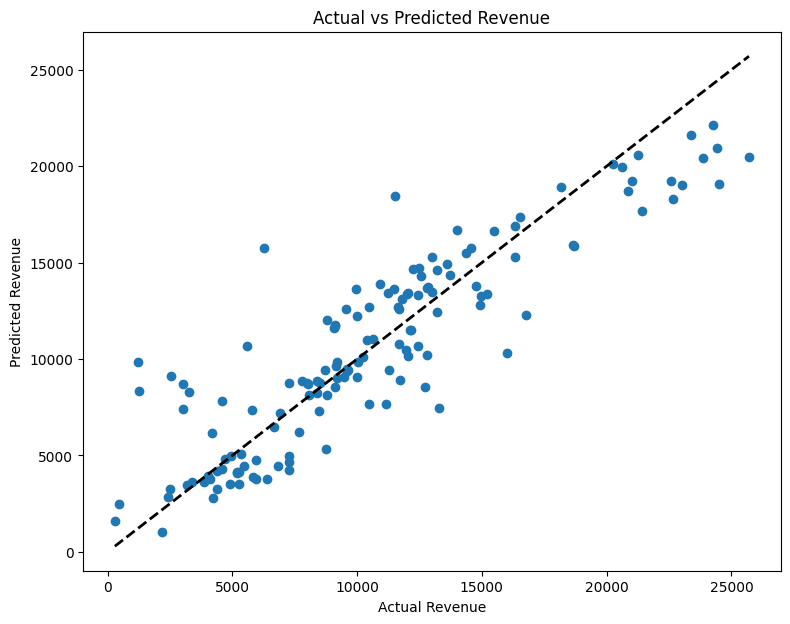

In [ ]:
#Plotting Actual vs Predicted :

plt.figure(figsize = (9, 7))
plt.scatter(y_train, y_pred)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw = 2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()

# increase size.



# New Section

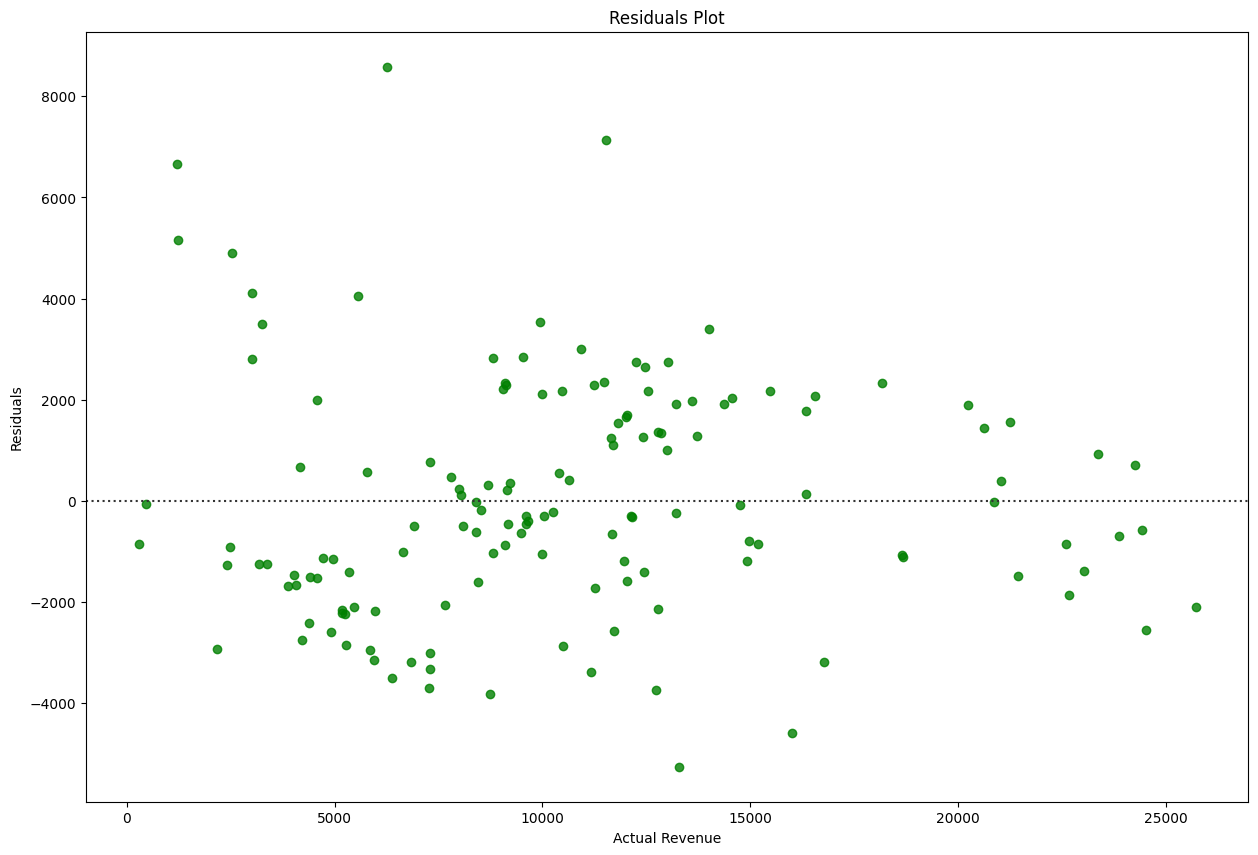

In [ ]:

# Plotting Residuals

plt.figure(figsize = (15, 10))

sns.residplot(x = y_train,y =  y_pred, color = 'g')
plt.xlabel('Actual Revenue')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

In [ ]:
# How to use our linear Regression model to make predictions!

# passing coef into a table
coeff = lm.coef_
coeff.shape



# Reshaping
coeff = coeff.reshape(-1, 12)

# creating a DataFrame
coeff_df = pd.DataFrame(coeff, columns = nrw.drop('Revenue', axis = 1).columns)
coeff_df


,Visitors,Marketing Spend,Promo_No Promo,Promo_Promotion Blue,Promo_Promotion Red,Day_Name_Friday,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,0.972169,3.695615,-4295.87654,3724.69059,571.185949,738.005738,-352.308895,-902.241594,-155.867567,814.821481,150.084913,-292.494076


In [ ]:
Day = 'Day_Name_Friday'
Visitors = 8000
Marketing_Spend = 5000
Promo = 'Promo_Promotion Red'

pred1 = (lm.intercept_) + (coeff_df[Day].values[0]*1) + (coeff_df['Visitors'].values[0] * Visitors) + (coeff_df['Marketing Spend'].values[0] * Marketing_Spend) + (coeff_df[Promo].values[0]* 1)

print('The prediction Revenue is: ', pred1)

The prediction Revenue is:  31625.267849885422
